# YOLO26 inference 

**Goal.** Load the model trained in `yolo-v1.ipynb` and run inference: single image, top-K, batch from folder, with visualisations.

**Changes:**
- Reusable `predict(...)` helper.
- Top-1 *and* top-K display (top-5 in code, even though we only have 3 classes — the pattern matters).
- Side-by-side image + probability-bar chart.
- Batch inference on a folder.
- A pitfalls section covering the most common things that go wrong in production.


## 1. Imports


In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from ultralytics import YOLO

## 2. Load the trained model

Point this to wherever your `best.pt` lives. After training in the previous notebook, that's `runs/classify/rps_yolo26n/weights/best.pt`. 


In [2]:
MODEL_PATH = 'runs/classify/rps_yolo26n/weights/best.pt'

model = YOLO(MODEL_PATH)
print('classes:', model.names)    # dict {idx: name}

classes: {0: 'paper', 1: 'rock', 2: 'scissors'}


## 3. Single-image prediction

Just call the model on a path. Ultralytics handles loading, resizing, and normalisation internally.


In [3]:
IMG_PATH = 'paper01-000.png'    # change me

results = model(IMG_PATH, verbose=False)
r = results[0]

top1_idx  = int(r.probs.top1)
top1_name = r.names[top1_idx]
top1_conf = float(r.probs.top1conf)

print(f'predicted : {top1_name}  ({top1_conf*100:.2f}%)')

predicted : paper  (100.00%)


## 4. Top-K predictions

Even with only 3 classes, looking at the *full distribution* tells you whether the model is confidently wrong or just uncertain — useful when deciding whether to flag predictions for human review.


In [4]:
def top_k(result, k=5):
    """Return list of (class_name, probability) sorted desc."""
    probs = result.probs.data.cpu().numpy()
    idx = np.argsort(probs)[::-1][:k]
    return [(result.names[int(i)], float(probs[i])) for i in idx]

for name, p in top_k(r, k=5):
    print(f'  {name:<10} {p*100:6.2f}%')

  paper      100.00%
  scissors     0.00%
  rock         0.00%


## 5. Visualise: image + probability bar


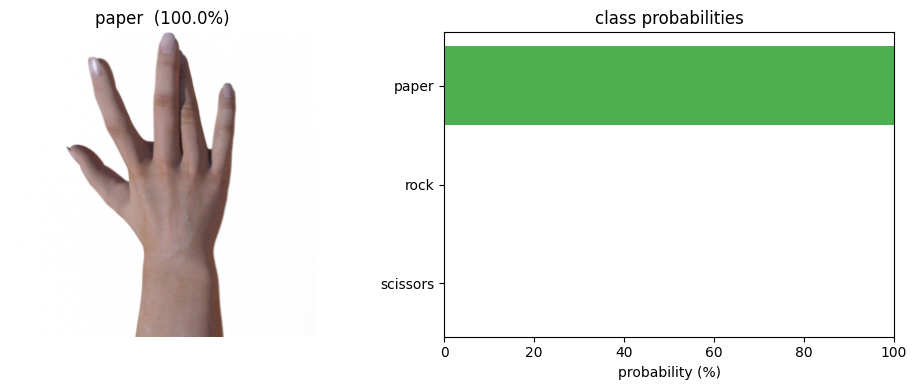

In [5]:
def plot_prediction(img_path, result):
    probs = result.probs.data.cpu().numpy()
    names = [result.names[i] for i in range(len(probs))]
    top   = int(result.probs.top1)

    img = Image.open(img_path)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].imshow(img)
    axes[0].set_title(f'{names[top]}  ({probs[top]*100:.1f}%)')
    axes[0].axis('off')

    y = np.arange(len(names))
    colors = ['#4caf50' if i == top else '#bdbdbd' for i in y]
    axes[1].barh(y, probs * 100, color=colors)
    axes[1].set_yticks(y, labels=names)
    axes[1].set_xlim(0, 100); axes[1].invert_yaxis()
    axes[1].set_xlabel('probability (%)')
    axes[1].set_title('class probabilities')
    plt.tight_layout(); plt.show()

plot_prediction(IMG_PATH, r)

## 6. Batch inference on a folder

Calling `model([list_of_paths])` is faster than looping — Ultralytics batches the work internally. For a large folder, pass the folder path directly.


In [ ]:
# FOLDER = '.'    # any folder with .png/.jpg images

# paths = sorted(
#     str(p) for p in Path(FOLDER).iterdir()
#     if p.suffix.lower() in {'.png', '.jpg', '.jpeg'}
# )

# if not paths:
#     print(f'No images in {FOLDER!r}')
# else:
#     print(f'Running inference on {len(paths)} images...')
#     results = model(paths, verbose=False)
#     for path, res in zip(paths, results):
#         idx = int(res.probs.top1)
#         print(f'  {Path(path).name:<35} → {res.names[idx]:<10} ({float(res.probs.top1conf)*100:5.1f}%)')

Running inference on 1 images...
  paper01-000.png                     → paper      (100.0%)


### 6.1 Show a grid of predictions


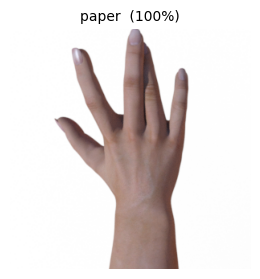

In [ ]:
# if paths:
#     n = min(12, len(paths))
#     plt.figure(figsize=(12, 8))
#     for i in range(n):
#         ax = plt.subplot(3, 4, i + 1)
#         plt.imshow(Image.open(paths[i]))
#         res = results[i]
#         idx = int(res.probs.top1)
#         ax.set_title(f'{res.names[idx]}  ({float(res.probs.top1conf)*100:.0f}%)', fontsize=10)
#         plt.axis('off')
#     plt.tight_layout(); plt.show()


## 7. Common pitfalls

| symptom                                          | likely cause                                                                       | fix                                                              |
|--------------------------------------------------|------------------------------------------------------------------------------------|------------------------------------------------------------------|
| `FileNotFoundError: best.pt`                     | run folder name doesn't match (`train` vs `rps_yolo26n` vs `train2`)               | check `runs/classify/` — pick the right subfolder.               |
| All predictions in one class with high confidence| wrong dataset folder structure (one class folder accidentally empty during train) | check `train_batch0.jpg` in the run dir; retrain with valid data. |
| Confidence ≈ 1/num_classes                       | model loaded was randomly initialised (you forgot the `.pt`)                       | always pass `'best.pt'` or a known checkpoint, not `.yaml`.      |
| Predictions differ between training-time val and inference | image preprocessing mismatch (custom resizing vs default `CenterCrop`)   | use Ultralytics' built-in `model(path)` and don't pre-resize.    |
| Slow inference per image                         | calling `model(path)` in a Python loop                                             | pass a list/folder; Ultralytics batches automatically.           |


## 8. Export for deployment (one-liner)

When you're happy with `best.pt`, export it for whatever runtime you ship to. ONNX is the most portable.


In [ ]:
# Uncomment to export. ONNX needs `uv add onnx`.
# onnx_path = model.export(format='onnx', dynamic=True, opset=17)
# print('exported →', onnx_path)

## 9. Recap — the four-notebook journey

| notebook                                       | role                                                  |
|------------------------------------------------|--------------------------------------------------------|
| `yolo-v0.ipynb`                   | concepts: what YOLO is and when to use it             |
| `yolo_img_classification.ipynb`       | classification with YOLO26, every detail explained    |
| `yolo-v1.ipynb`                       | runnable training (this is the *do* part)             |
| **`test-yolo.ipynb`** (this notebook) | runnable inference + production hand-off              |

You now have a working classifier and the conceptual base to swap to a different YOLO size, switch to detection or segmentation, or export to a phone. Good luck shipping it.
